In [19]:
# importing necessary libraries
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B
from qiskit_machine_learning.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit, RawFeatureVector
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation

# setting the random seed for reproducibility
algorithm_globals.random_seed = 42

In [20]:
# loading the necessary datasets (X_pca_df800.csv is the PCA reduced dataset and X_isomap_df800.csv is the Isomap reduced dataset)
sample_pca_reduced_df = pd.read_csv(r"X_pca_df800.csv")
sample_isomap_reduced_df = pd.read_csv(r"X_isomap_df800.csv")
print(sample_isomap_reduced_df.shape)
print(sample_pca_reduced_df.shape)
print(sample_isomap_reduced_df.head(2))
print(sample_pca_reduced_df.head(2))

(800, 64)
(800, 64)
        iso_0       iso_1       iso_2       iso_3      iso_4       iso_5  \
0  -53.671696   31.974530  -24.269207   19.209847  14.136245    1.007176   
1  155.376024 -154.436262  209.230539 -128.866146  79.643210 -100.940090   

       iso_6       iso_7      iso_8      iso_9  ...     iso_54    iso_55  \
0  -7.544981    6.892984  24.187482 -19.671826  ...  17.529770 -0.488861   
1 -43.293867  126.229685 -23.773667  38.726918  ...  22.316247 -2.885783   

     iso_56     iso_57     iso_58     iso_59     iso_60     iso_61     iso_62  \
0  6.515017 -10.711217   1.107419  -9.427081   5.073199  -7.731891 -26.742105   
1  2.772488 -18.489251  26.095577 -12.193787 -31.733542  42.559637  -9.496247   

      iso_63  
0   0.392372  
1 -21.525337  

[2 rows x 64 columns]
       pca_0     pca_1      pca_2     pca_3      pca_4     pca_5     pca_6  \
0 -20.244039 -6.718547 -11.839866  3.007421   4.245244 -3.932463  0.380121   
1  39.612205 -9.017961  -9.869754  7.911266 -12.857755

In [25]:
# converting the dataframes to numpy arrays for further processing and use in quantum circuits
X_isomap = sample_isomap_reduced_df.values.astype(float)
print(X_isomap[1:2])
X_pca = sample_pca_reduced_df.values.astype(float)
print(X_pca[1:2])
X_pca_10 = sample_pca_reduced_df.iloc[:, :10].values.astype(float)
print(X_pca_10[1:2])

[[ 155.3760238  -154.43626227  209.23053919 -128.86614551   79.64321045
  -100.94008998  -43.29386655  126.22968468  -23.773667     38.72691774
  -114.00353174   26.1851463   -49.62829056  -10.33821264   65.88513149
    27.31477444  -11.84392164  -16.84821113   33.81594779   50.47847699
   -17.86206496   25.93862439   26.61978606    1.9791091    15.77001822
    28.00131098   14.7057921   -47.61912749  -29.98236026   18.76865502
   -28.19537929  -21.33641427   14.30387408   -1.23081776   -2.05016156
   -42.08089216   23.62863039   -0.44385232  -19.8831307    28.94638535
    -7.55750088  -16.68111468   -9.34514014   -8.36365186   43.58517143
    -4.46439819    3.1438883    -4.97048737  -18.12141737    8.40181733
    -2.59973907   -6.28149509   -0.40681343  -10.32343617   22.31624707
    -2.88578273    2.77248814  -18.48925114   26.09557721  -12.19378723
   -31.73354216   42.55963676   -9.49624653  -21.52533661]]
[[ 39.6122053   -9.01796079  -9.86975353   7.91126563 -12.85775492
   -0.139

In [26]:
# create array of shape (800,2) as the labels (positive [1,0], and negative [0,1]) in this dataset first 400 samples are negative and last 400 samples are positive
num_samples = 400
y_one_hot = np.array([[0, 1]] * num_samples + [[1, 0]] * num_samples)
print(y_one_hot.shape)
print(y_one_hot[0:2])
print(y_one_hot[-2:])

(800, 2)
[[0 1]
 [0 1]]
[[1 0]
 [1 0]]


In [27]:
# def pad_to_power_of_2(data):
#     """Pad data with zeros to the nearest power of 2"""
#     next_power = 2 ** int(np.ceil(np.log2(len(data))))
#     padded_data = np.zeros(next_power)
#     padded_data[:len(data)] = data  # Retaining original values
#     return padded_data

In [36]:
# normalizing the training datasets for RawFeatureVector and ZZFeatureMap
from numpy.linalg import norm

def normalize(X):
    return np.array([x / norm(x) if norm(x) > 0 else x for x in X])

X_train_pca_norm = normalize(X_pca)
X_train_isomap_norm = normalize(X_isomap)
X_train_pca_10_norm = normalize(X_pca_10)

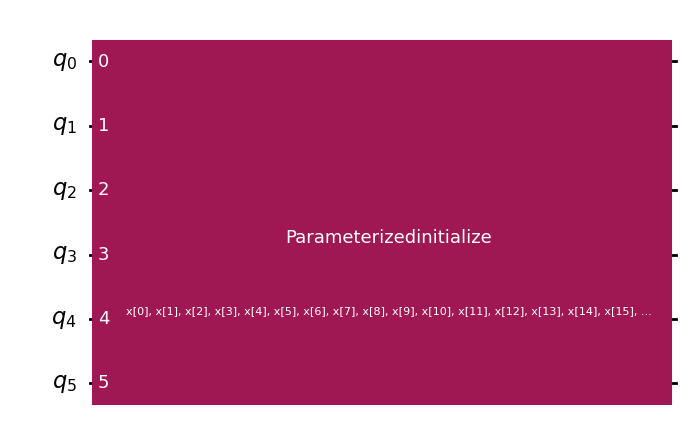

In [37]:
# creating a quantum circuit for the feature map using the RawFeatureVector class
num_features = 64
feature_map_raw = RawFeatureVector(num_features)
display(feature_map.draw(output="mpl"))

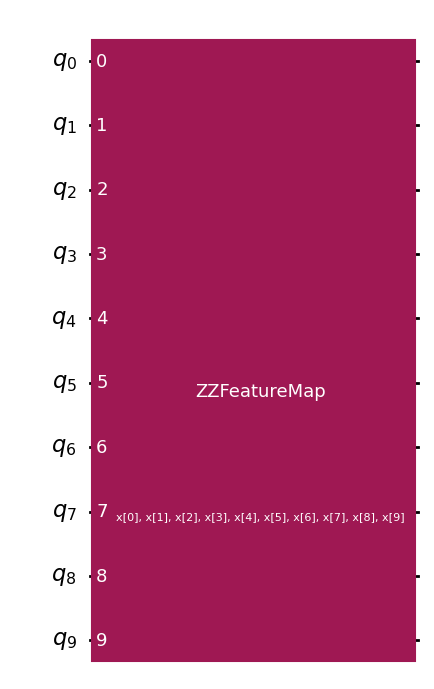

In [38]:
# creating a quantum circuit for the feature map using the ZZFeatureMap class for the first 10 features in pca dataset
from qiskit.circuit.library import ZZFeatureMap

feature_map_ZZ = ZZFeatureMap(feature_dimension=10, reps=2, entanglement='linear')
display(feature_map_ZZ.draw(output="mpl"))

In [39]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()


In [43]:
# setting the optimizer for the VQC algorithm
from qiskit.primitives import StatevectorSampler as Sampler
sampler = Sampler()
# construct ansatz, and optimizer
from qiskit.circuit.library import TwoLocal
ansatz_raw = TwoLocal(num_qubits=6, rotation_blocks="ry", entanglement_blocks="cz", reps=1)
# create a new ansatz instance for ZZFeatureMap
ansatz_zz = TwoLocal(
    num_qubits=10,
    rotation_blocks="ry",
    entanglement_blocks="cz",
    reps=1
)

In [44]:
# construct variational quantum classifier with RawFeatureVector feature map and ansatz with 6 qubits for pca dataset
vqc_pca_raw = VQC(
    feature_map=feature_map_raw,
    ansatz=ansatz_raw,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [45]:
# construct variational quantum classifier with RawFeatureVector feature map and ansatz with 6 qubits for isomap dataset
vqc_isomap_raw = VQC(
    feature_map=feature_map_raw,
    ansatz=ansatz_raw,
    loss="cross_entropy",
    optimizer=COBYLA(maxiter=30),
    callback=callback_graph,
    sampler=sampler,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


In [46]:
# construct variational quantum classifier with ZZFeatureMap feature map and ansatz with 10 qubits for 10 components in pca dataset
vqc_pca10_ZZ = VQC(
    feature_map=feature_map_ZZ,
    ansatz=ansatz_zz,
    optimizer=COBYLA(maxiter=30),
    loss="cross_entropy",
    sampler=sampler,
    callback=callback_graph
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


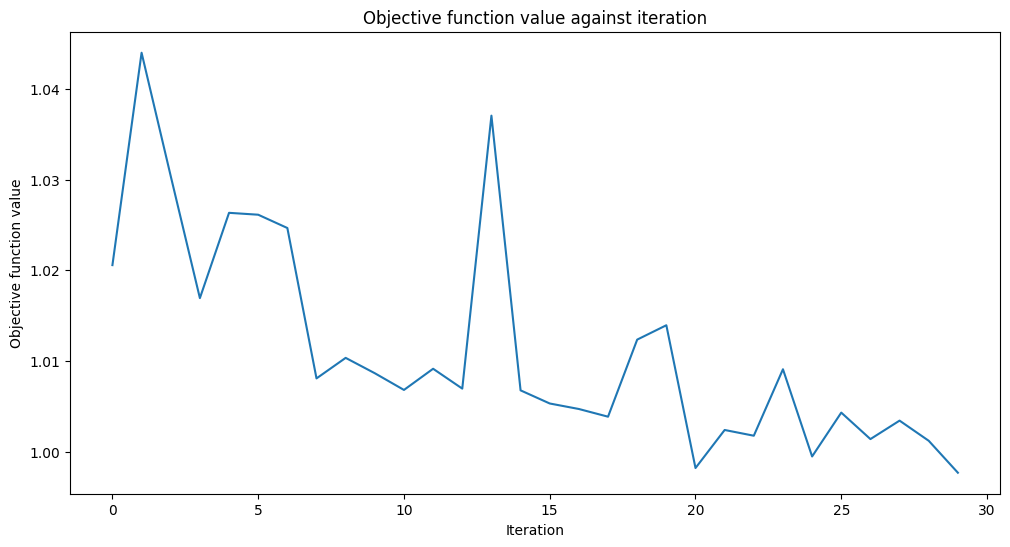

In [47]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to pca dataset with RawFeatureVector feature map and ansatz with 6 qubits
vqc_pca_raw.fit(X_train_pca_norm, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)


In [48]:
# score classifier on pca dataset with RawFeatureVector feature map and ansatz with 6 qubits
vqc_pca_raw.score(X_train_pca_norm, y_one_hot)
# evaluate data points
y_predict = vqc_pca_raw.predict(X_train_pca_norm)

from sklearn.metrics import accuracy_score

# Predict labels for the training set
y_pred = np.argmax(y_predict, axis=1)

# Convert one-hot encoded `y_one_hot` back to class labels
y_true = np.argmax(y_one_hot, axis=1)

# Compute accuracy
acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", acc)

Training Accuracy: 0.53625


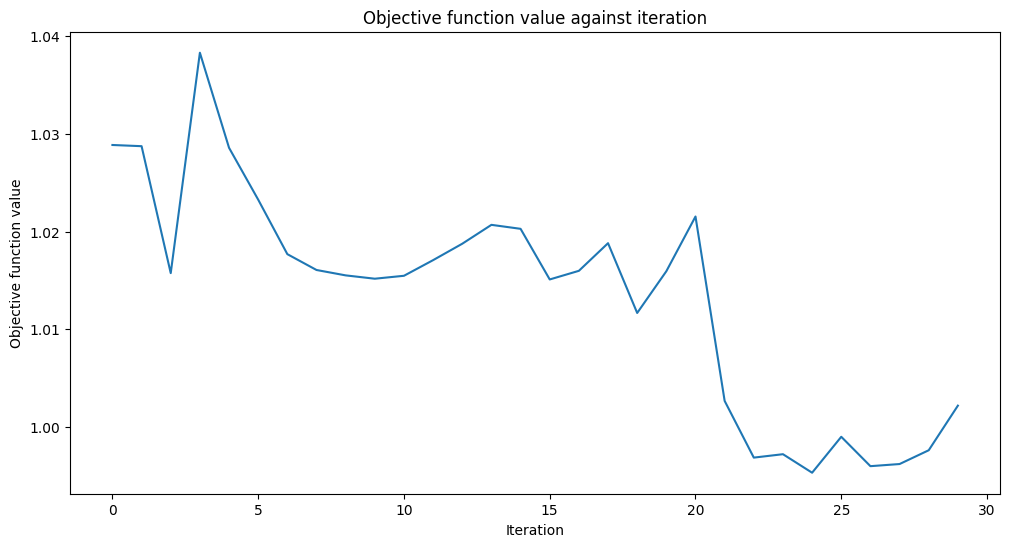

In [49]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to isomap dataset with RawFeatureVector feature map and ansatz with 6 qubits
vqc_isomap_raw.fit(X_train_isomap_norm, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

In [50]:
# score classifier on isomap dataset with RawFeatureVector feature map and ansatz with 6 qubits
vqc_isomap_raw.score(X_train_isomap_norm, y_one_hot)
# evaluate data points
y_predict = vqc_isomap_raw.predict(X_train_isomap_norm)

from sklearn.metrics import accuracy_score

# Predict labels for the training set
y_pred = np.argmax(y_predict, axis=1)

# Convert one-hot encoded `y_one_hot` back to class labels
y_true = np.argmax(y_one_hot, axis=1)

# Compute accuracy
acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", acc)

Training Accuracy: 0.55375


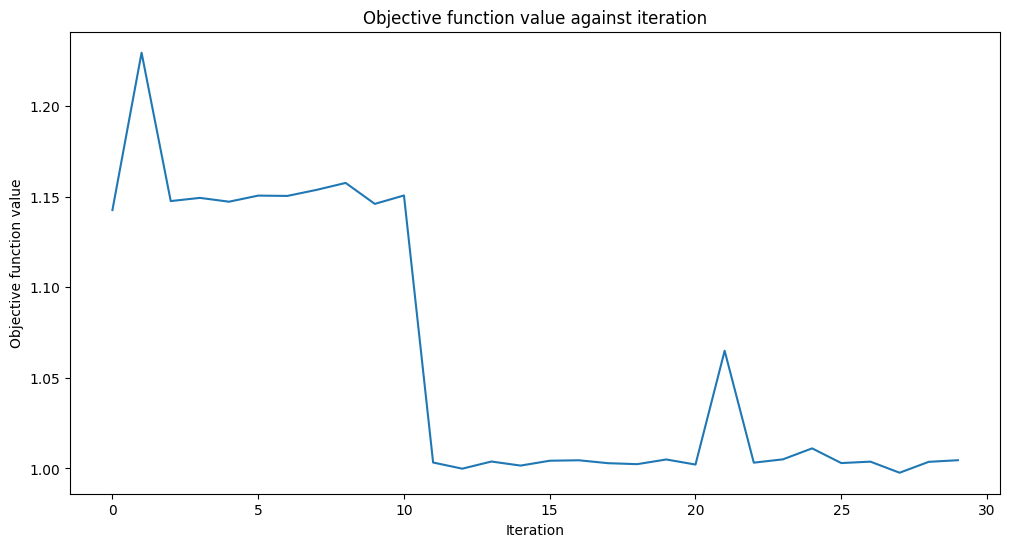

In [51]:
# create empty array for callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

# fit classifier to first 10 pca components dataset with ZZFeatureMap feature map and ansatz with 10 qubits
vqc_pca10_ZZ.fit(X_train_pca_10_norm, y_one_hot)

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)


In [52]:
# score classifier on first 10 components in pca dataset with ZZFeatureMap feature map and ansatz with 10 qubits
vqc_pca10_ZZ.score(X_train_pca_10_norm, y_one_hot)
# evaluate data points
y_predict = vqc_pca10_ZZ.predict(X_train_pca_10_norm)

from sklearn.metrics import accuracy_score

# Predict labels for the training set
y_pred = np.argmax(y_predict, axis=1)

# Convert one-hot encoded `y_one_hot` back to class labels
y_true = np.argmax(y_one_hot, axis=1)

# Compute accuracy
acc = accuracy_score(y_true, y_pred)
print("Training Accuracy:", acc)

Training Accuracy: 0.51375


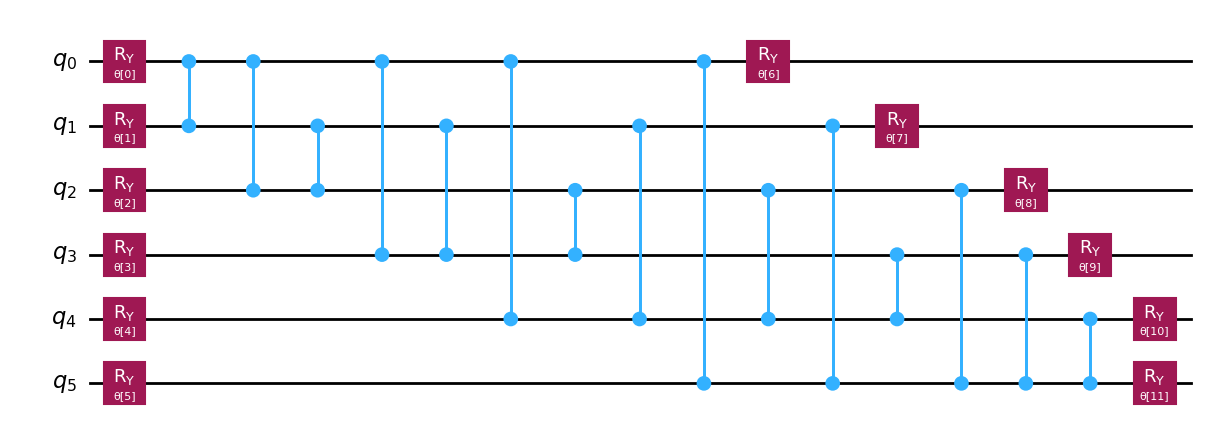

In [53]:
# looking at the ansatz circuit for the VQC with RawFeatureVector feature map and ansatz with 6 qubits for pca dataset
vqc_pca_raw.ansatz.decompose().draw("mpl")

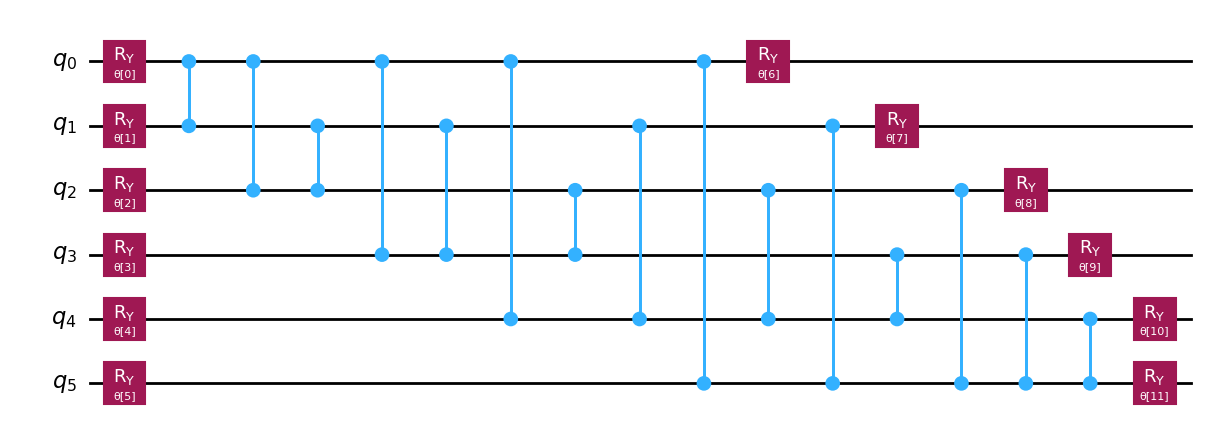

In [54]:
# looking at the ansatz circuit for the VQC with RawFeatureVector feature map and ansatz with 6 qubits for isomap dataset
vqc_isomap_raw.ansatz.decompose().draw("mpl")

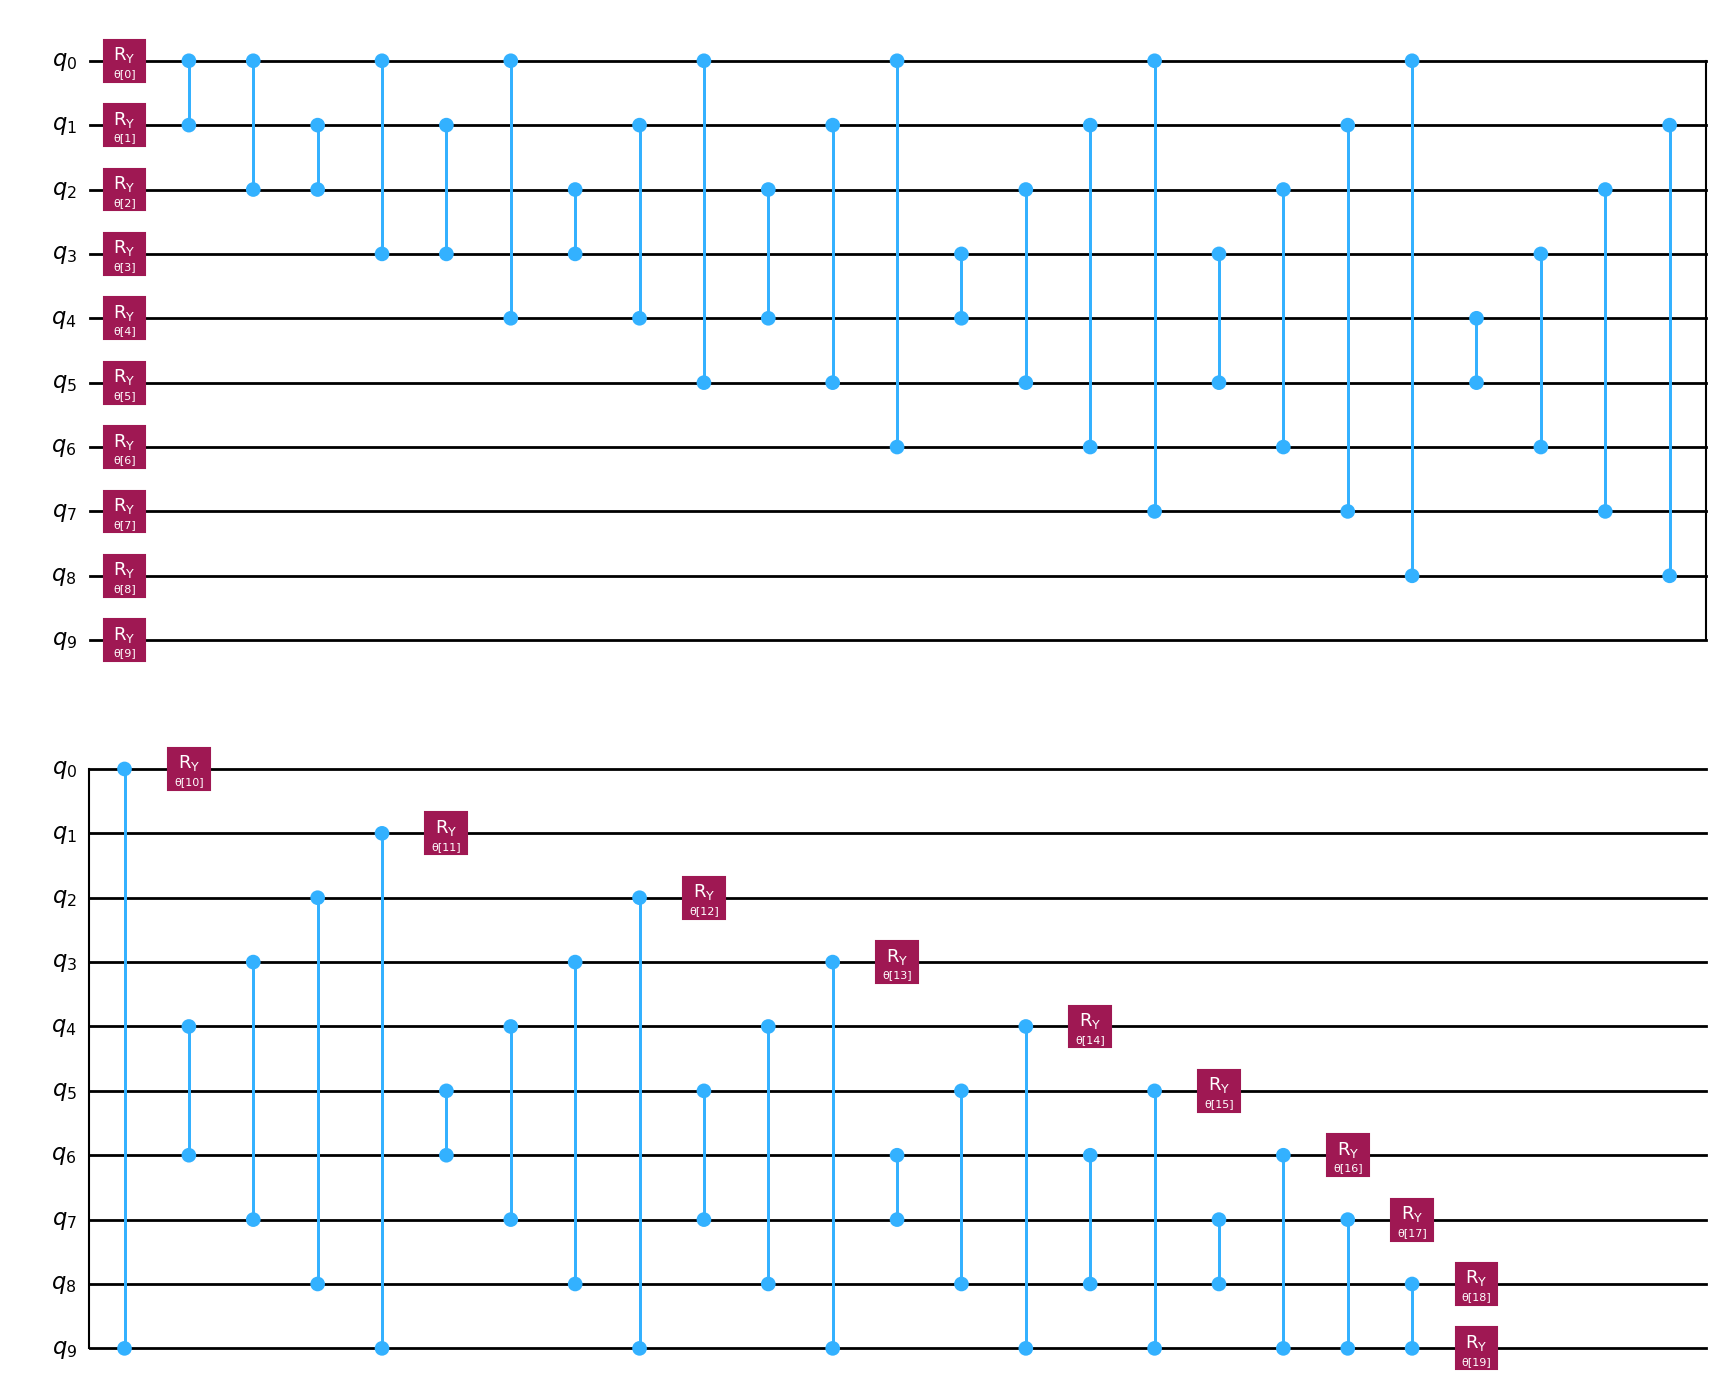

In [55]:
# looking at the ansatz circuit for the VQC with ZZFeatureMap feature map and ansatz with 10 qubits for first 10 components in pca dataset
vqc_pca10_ZZ.ansatz.decompose().draw("mpl")

In [56]:
# libraries for classical neural network model 
# !pip install torch
import torch
import torch.nn as nn
import torch.optim as optim

In [57]:
# Convert to float32 for PyTorch (PCA dataset)
X = sample_pca_reduced_df.values.astype(np.float32)
y = y_one_hot.astype(np.float32)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)
y_labels = torch.argmax(y_tensor, dim=1)  # Convert one-hot to class indices

In [58]:
# Define the model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

# Instantiate model, loss, and optimizer
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

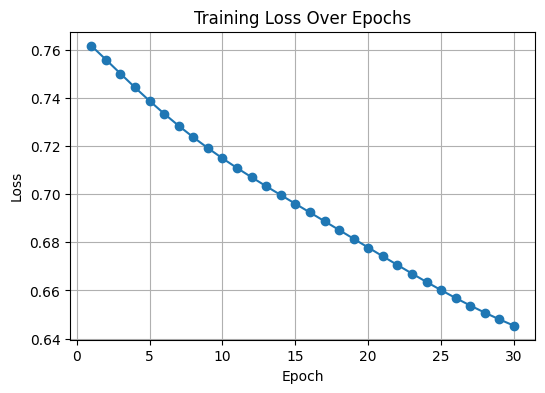

In [59]:
# Store losses for each epoch
losses = []

# Train the model
for epoch in range(30):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())  # Save loss per epoch

# Plot the loss curve
plt.plot(range(1, 31), losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [60]:
# Evaluate on the same data
with torch.no_grad():
    predictions = model(X_tensor)
    correct = (torch.argmax(predictions, dim=1) == y_labels).sum().item()
    total = y_labels.shape[0]
    accuracy = correct / total

print(f"Train/Test accuracy (same set): {accuracy * 100:.2f}%")

Train/Test accuracy (same set): 65.25%


In [62]:
# Convert to float32 for PyTorch (isomap dataset)
X = sample_isomap_reduced_df.values.astype(np.float32)
y = y_one_hot.astype(np.float32)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)
y_labels = torch.argmax(y_tensor, dim=1)  # Convert one-hot to class indices

In [63]:
# Define the model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

# Instantiate model, loss, and optimizer
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

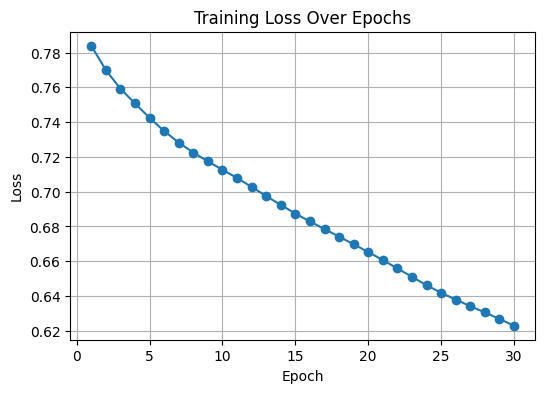

In [64]:
# Store losses for each epoch
losses = []

# Train the model
for epoch in range(30):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())  # Save loss per epoch

# Plot the loss curve
plt.plot(range(1, 31), losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [65]:
# Evaluate on the same data
with torch.no_grad():
    predictions = model(X_tensor)
    correct = (torch.argmax(predictions, dim=1) == y_labels).sum().item()
    total = y_labels.shape[0]
    accuracy = correct / total

print(f"Train/Test accuracy (same set): {accuracy * 100:.2f}%")

Train/Test accuracy (same set): 70.25%
